In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
import tempfile
import pickle as pkl
import sys
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from scipy.special import logit, softmax
from scipy.stats import wilcoxon, combine_pvalues

from one.api import ONE
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os
from os.path import join
from glob import glob
from tqdm import tqdm
from iblatlas.plots import plot_swanson_vector
import matplotlib as mpl
import seaborn as sns

In [3]:
df_final_true_zeta = pd.read_parquet(
    "../data/collected_results/zeta_pseudo_200/collected_results_stage3.pqt"
)

df_final_shifted = pd.read_parquet(
    "../data/collected_results/shifted_ephys/collected_results_stage3.pqt"
)

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
def plot_significant_regions(df_sessionfilter, mask):
    acronyms = df_sessionfilter["region"][mask].values
    values = df_sessionfilter["valuesminusnull_median"][mask].values

    fig, ax = plt.subplots(figsize=(16, 4), layout="constrained")
    cmap = mpl.cm.viridis
    # cmap.set_extremes(under="cyan", over="magenta")
    plot_swanson_vector(
        acronyms,
        values,
        ax=ax,
        cmap=cmap,
        annotate=True,
        annotate_list=acronyms,
        fontsize=12,
        empty_color="silver",
        mask=acronyms,
        mask_color="wheat",
        show_cbar=True,
    )
    ax.axis("off")

In [6]:
dfsessionfilterold = df_final_shifted[df_final_shifted["n_sessions"] >= 2]
dfsessionfilternew = df_final_true_zeta[df_final_true_zeta["n_sessions"] >= 2]

In [9]:
np.sum(dfsessionfilterold["sig_combined_corrected"] == True), len(dfsessionfilterold)

(np.int64(104), 165)

In [11]:
np.sum(dfsessionfilternew["sig_combined"] == True), len(dfsessionfilternew)

(np.int64(43), 210)

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/iblatlas/regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


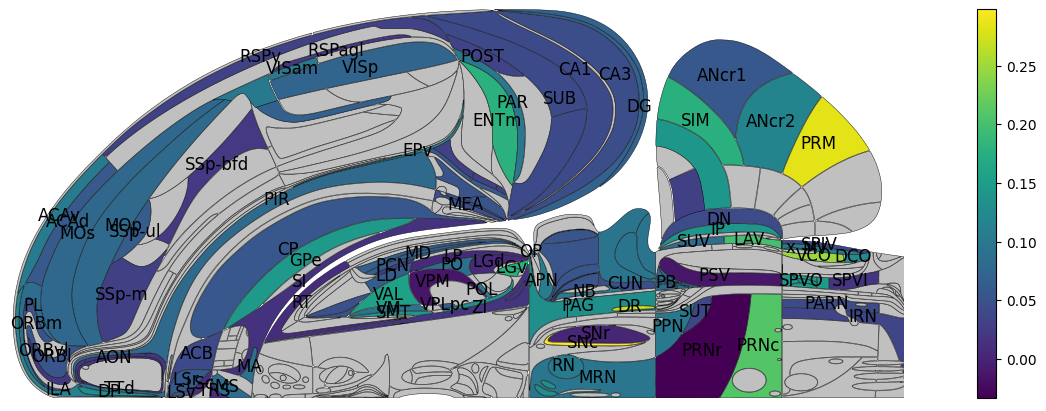

In [25]:
plot_significant_regions(
    dfsessionfilterold, mask=dfsessionfilterold["sig_combined_corrected"] == True
)

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/iblatlas/regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


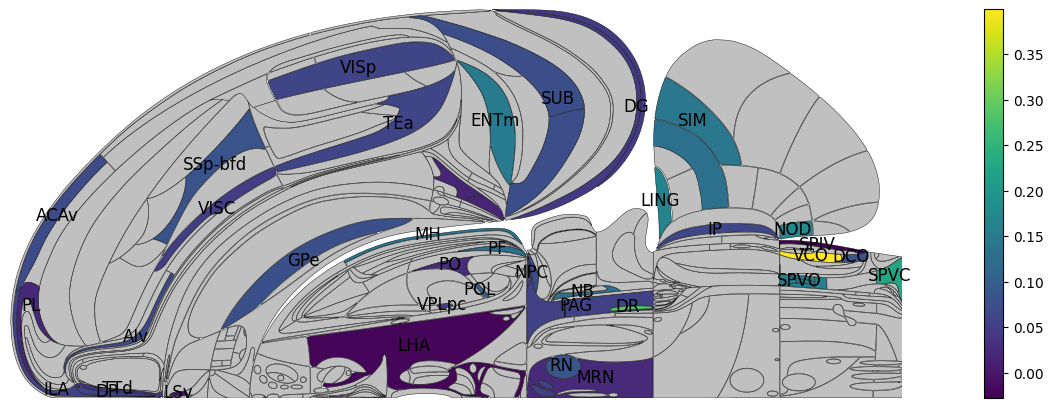

In [26]:
plot_significant_regions(dfsessionfilternew, mask=dfsessionfilternew["sig_combined"])

In [13]:
df_proper_pseudo = pd.read_parquet(
    "../data/collected_results/zeta_false_pseudo/collected_results_stage2.pqt"
)
df_shifted = pd.read_parquet(
    "../data/collected_results/shifted_ephys/collected_results_stage2.pqt"
)

In [15]:
from manifold.compute_all_stats import (
    reformat_df,
    compute_stats_over_pseudo_ids,
    significance_by_region,
)

In [24]:
df_shifted

,subject,eid,region,n_units,n_pseudo,score,p-value,median-null,n_trials
0,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,AV,24.0,100.0,0.102465,0.099010,0.022152,462.0
1,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,CA1,5.0,100.0,-0.009508,0.316832,-0.017405,462.0
2,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,LD,6.0,100.0,0.088760,0.188119,0.059621,462.0
3,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,LGd,30.0,100.0,-0.083403,0.881188,-0.047529,462.0
4,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,VAL,36.0,100.0,0.153993,0.019802,0.043280,462.0
...,...,...,...,...,...,...,...,...,...
1584,ZM_3003,fe1fd79f-b051-411f-a0a9-2530a02cc78d,OP,8.0,100.0,0.063130,0.009901,-0.000560,525.0
1585,ZM_3003,fe1fd79f-b051-411f-a0a9-2530a02cc78d,PAG,14.0,100.0,0.212251,0.039604,0.140193,525.0
1586,ZM_3003,fe1fd79f-b051-411f-a0a9-2530a02cc78d,RSPagl,18.0,100.0,0.080886,0.009901,-0.004762,525.0
1587,ZM_3003,fe1fd79f-b051-411f-a0a9-2530a02cc78d,SI,7.0,100.0,0.045806,0.069307,-0.001254,525.0


In [25]:
df_compare = df_proper_pseudo[df_proper_pseudo["eid"].isin(df_shifted["eid"].unique())]

In [36]:
df_shifted[df_shifted["p-value"] < 0.05]

,subject,eid,region,n_units,n_pseudo,score,p-value,median-null,n_trials
4,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,VAL,36.0,100.0,0.153993,0.019802,0.043280,462.0
6,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,ZI,5.0,100.0,0.067019,0.009901,0.011131,462.0
7,CSHL045,46794e05-3f6a-4d35-afb3-9165091a5a74,GRN,28.0,100.0,0.594311,0.009901,0.404224,565.0
8,CSHL045,46794e05-3f6a-4d35-afb3-9165091a5a74,NOD,20.0,100.0,0.618487,0.019802,0.437279,565.0
14,CSHL045,7939711b-8b4d-4251-b698-b97c1eaa846e,LIN,11.0,100.0,0.154366,0.029703,0.031364,586.0
...,...,...,...,...,...,...,...,...,...
1582,ZM_3003,fe1fd79f-b051-411f-a0a9-2530a02cc78d,MEA,10.0,100.0,0.021006,0.019802,-0.020587,525.0
1584,ZM_3003,fe1fd79f-b051-411f-a0a9-2530a02cc78d,OP,8.0,100.0,0.063130,0.009901,-0.000560,525.0
1585,ZM_3003,fe1fd79f-b051-411f-a0a9-2530a02cc78d,PAG,14.0,100.0,0.212251,0.039604,0.140193,525.0
1586,ZM_3003,fe1fd79f-b051-411f-a0a9-2530a02cc78d,RSPagl,18.0,100.0,0.080886,0.009901,-0.004762,525.0


In [19]:
df_proper_pseudo = pd.read_parquet(
    "../data/collected_results/zeta_pseudo_200/collected_results_stage2.pqt"
)

In [21]:
df_all = pd.read_parquet("../data/collected_results/zeta_pseudo_200/collected_results_stage1.pqt")

In [34]:
(df_proper_pseudo["p-value"] < 0.05).sum() / len(df_proper_pseudo)

np.float64(0.11088790678987545)

In [35]:
significant = df_proper_pseudo["p-value"] < 0.05

In [45]:
df_proper_pseudo[significant]

,subject,eid,region,n_units,n_pseudo,score,p-value,median-null,n_trials
7,CSHL045,46794e05-3f6a-4d35-afb3-9165091a5a74,GRN,28.0,200.0,0.629096,0.014925,0.262988,565.0
8,CSHL045,46794e05-3f6a-4d35-afb3-9165091a5a74,NOD,20.0,200.0,0.619077,0.024876,0.305762,565.0
9,CSHL045,46794e05-3f6a-4d35-afb3-9165091a5a74,PRP,27.0,200.0,0.551522,0.044776,0.293259,565.0
41,CSHL047,b52182e7-39f6-4914-9717-136db589706e,MRN,6.0,200.0,0.091576,0.039801,0.015512,487.0
58,CSHL049,d2918f52-8280-43c0-924b-029b2317e62c,LSc,22.0,200.0,0.215288,0.019900,0.019512,648.0
...,...,...,...,...,...,...,...,...,...
2471,ibl_witten_29,821f1883-27f3-411d-afd3-fb8241bbc39a,VISC,27.0,200.0,0.623306,0.004975,0.141322,571.0
2472,ibl_witten_29,86b6ba67-c1db-4333-add0-f8105ea6e363,LAV,5.0,200.0,0.495194,0.014925,0.155269,549.0
2473,ibl_witten_29,86b6ba67-c1db-4333-add0-f8105ea6e363,MRN,6.0,200.0,0.302626,0.029851,0.049532,549.0
2485,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,CP,21.0,200.0,0.558633,0.004975,0.122344,404.0


In [48]:
df_proper_pseudo

,subject,eid,region,n_units,n_pseudo,score,p-value,median-null,n_trials
0,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,AV,24.0,200.0,0.107437,0.567164,0.125885,462.0
1,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,CA1,5.0,200.0,-0.008710,0.601990,-0.004141,462.0
2,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,LD,6.0,200.0,0.081080,0.641791,0.125857,462.0
3,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,LGd,30.0,200.0,-0.075543,0.860697,0.005196,462.0
4,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,VAL,36.0,200.0,0.132469,0.592040,0.166467,462.0
...,...,...,...,...,...,...,...,...,...
2484,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,CEA,10.0,200.0,0.159767,0.184080,0.052817,404.0
2485,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,CP,21.0,200.0,0.558633,0.004975,0.122344,404.0
2486,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,GPe,41.0,200.0,0.576780,0.024876,0.233793,404.0
2487,ibl_witten_32,08102cfc-a040-4bcf-b63c-faa0f4914a6f,ACB,6.0,200.0,0.181331,0.089552,0.030257,357.0
